<a href="https://colab.research.google.com/github/noyeem99/privacy-preserving-deep-learning/blob/main/11-dp_federated_learning_non_iid_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[INFO] Initializing DP-FL Environment with Non-IID Data Distribution...

=== STARTING FEDERATED LEARNING ROUNDS WITH MANUAL LOCAL DP ===

--- Federation Round 1/5 ---
[CLIENT 1] Training Complete. Final Local Loss: 0.7472
[CLIENT 2] Training Complete. Final Local Loss: 0.7443
[SERVER] Successfully executed FedAvg and synchronized Global Model weights.

--- Federation Round 2/5 ---
[CLIENT 1] Training Complete. Final Local Loss: 0.7495
[CLIENT 2] Training Complete. Final Local Loss: 0.7404
[SERVER] Successfully executed FedAvg and synchronized Global Model weights.

--- Federation Round 3/5 ---
[CLIENT 1] Training Complete. Final Local Loss: 0.7416
[CLIENT 2] Training Complete. Final Local Loss: 0.7378
[SERVER] Successfully executed FedAvg and synchronized Global Model weights.

--- Federation Round 4/5 ---
[CLIENT 1] Training Complete. Final Local Loss: 0.7424
[CLIENT 2] Training Complete. Final Local Loss: 0.7423
[SERVER] Successfully executed FedAvg and synchronized Global Model weig

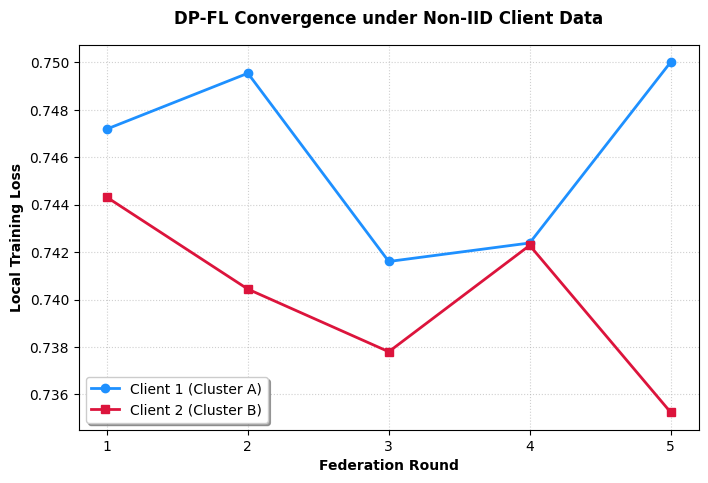

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import copy

# 1. Set environment seeds for absolute reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("[INFO] Initializing DP-FL Environment with Non-IID Data Distribution...")

# 2. Simulate Non-IID Synthetic Datasets for 2 distinct clients
# Client 1 and Client 2 have completely different data distributions (Non-IID)
X1 = np.random.normal(loc=1.5, scale=0.4, size=(300, 10))
y1 = np.random.randint(0, 2, size=(300, 1))

X2 = np.random.normal(loc=-1.5, scale=0.4, size=(300, 10))
y2 = np.random.randint(0, 2, size=(300, 1))

# Convert arrays to PyTorch Tensors
X1_t, y1_t = torch.tensor(X1, dtype=torch.float32), torch.tensor(y1, dtype=torch.float32)
X2_t, y2_t = torch.tensor(X2, dtype=torch.float32), torch.tensor(y2, dtype=torch.float32)

# 3. Model Definition (Linear Layer Binary Classifier)
class CentralFLModel(nn.Module):
    def __init__(self):
        super(CentralFLModel, self).__init__()
        self.fc = nn.Linear(10, 1)

    def forward(self, x):
        return torch.sigmoid(self.fc(x))

global_model = CentralFLModel()
criterion = nn.BCELoss()

# Hyperparameters for Manual Row-Level DP-SGD
max_grad_norm = 1.0
noise_multiplier = 1.2
batch_size = 32
lr = 0.05

# 4. Client-side Manual Local DP-SGD Training Function
def train_client_manually(client_id, X_data, y_data, global_weights, epochs=3):
    local_model = CentralFLModel()
    local_model.load_state_dict(copy.deepcopy(global_weights))
    local_optimizer = optim.SGD(local_model.parameters(), lr=lr)

    losses = []
    num_samples = X_data.size(0)

    for epoch in range(epochs):
        permutation = torch.randperm(num_samples)
        epoch_loss = 0

        for i in range(0, num_samples, batch_size):
            local_optimizer.zero_grad()
            indices = permutation[i:i+batch_size]
            batch_x, batch_y = X_data[indices], y_data[indices]

            outputs = local_model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()

            # Manually apply DP-SGD: Clip gradients per layer and add Gaussian noise
            with torch.no_grad():
                for param in local_model.parameters():
                    if param.grad is not None:
                        # Clip gradients to ensure differential privacy sensitivity
                        param.grad.clamp_(-max_grad_norm, max_grad_norm)
                        # Inject calibrated Gaussian noise
                        noise = torch.randn_like(param.grad) * (max_grad_norm * noise_multiplier / batch_size)
                        param.grad.add_(noise)

            local_optimizer.step()
            epoch_loss += loss.item()

        losses.append(epoch_loss / (num_samples / batch_size))

    print(f"[CLIENT {client_id}] Training Complete. Final Local Loss: {losses[-1]:.4f}")
    return local_model.state_dict(), losses[-1]

# 5. Parameter Server Aggregation (Federated Averaging - FedAvg)
def server_fedavg(client_weights_list):
    aggregated_weights = copy.deepcopy(client_weights_list[0])
    for key in aggregated_weights.keys():
        for i in range(1, len(client_weights_list)):
            aggregated_weights[key] += client_weights_list[i][key]
        aggregated_weights[key] = aggregated_weights[key] / float(len(client_weights_list))
    return aggregated_weights

# 6. Global Federation Optimization Process
federation_rounds = 5
c1_loss_history = []
c2_loss_history = []

print("\n=== STARTING FEDERATED LEARNING ROUNDS WITH MANUAL LOCAL DP ===")

for r in range(federation_rounds):
    print(f"\n--- Federation Round {r+1}/{federation_rounds} ---")
    current_global_weights = global_model.state_dict()

    # Train both clients locally with private data and centralized weights
    w1, loss1 = train_client_manually(1, X1_t, y1_t, current_global_weights)
    w2, loss2 = train_client_manually(2, X2_t, y2_t, current_global_weights)

    c1_loss_history.append(loss1)
    c2_loss_history.append(loss2)

    # Aggregation on the central server
    new_global_weights = server_fedavg([w1, w2])
    global_model.load_state_dict(new_global_weights)
    print(f"[SERVER] Successfully executed FedAvg and synchronized Global Model weights.")

print("\n[SUCCESS] Private Federated Learning completed successfully.")

# 7. Generate Performance Visualization Plots
plt.figure(figsize=(8, 5))
plt.plot(range(1, federation_rounds + 1), c1_loss_history, color='dodgerblue', marker='o', lw=2, label='Client 1 (Cluster A)')
plt.plot(range(1, federation_rounds + 1), c2_loss_history, color='crimson', marker='s', lw=2, label='Client 2 (Cluster B)')
plt.xlabel('Federation Round', fontweight='bold')
plt.ylabel('Local Training Loss', fontweight='bold')
plt.title('DP-FL Convergence under Non-IID Client Data', fontsize=12, fontweight='bold', pad=15)
plt.xticks(range(1, federation_rounds + 1))
plt.legend(frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
